# **MILESTONE 1**



TASK 1


In [1]:
from google.colab import drive
drive.mount('/content/drive',)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:

!mkdir -p ~/.kaggle

!cp /content/drive/MyDrive/kaggle/kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c dog-breed-identification -p /content/dog_breed_data/

 98% 680M/691M [00:03<00:00, 238MB/s]
100% 691M/691M [00:03<00:00, 181MB/s]


In [3]:
!kaggle competitions download -c dog-breed-identification -p/content/labels.csv


 98% 678M/691M [00:02<00:00, 311MB/s]
100% 691M/691M [00:02<00:00, 325MB/s]


In [4]:
import zipfile, os

zip_dir = "/content/labels.csv/"

for f in os.listdir(zip_dir):
    if f.endswith(".zip"):
        with zipfile.ZipFile(os.path.join(zip_dir, f), 'r') as zf:
            zf.extractall(zip_dir)

print("Files extracted:", os.listdir(zip_dir))

Files extracted: ['train', 'labels.csv', 'dog-breed-identification.zip', 'test', 'sample_submission.csv']


In [5]:
import pandas as pd
labels_path = os.path.join(zip_dir, "labels.csv")
labels_df = pd.read_csv(labels_path)

print("\nTotal labeled training images:", len(labels_df))
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    labels_df,
    test_size=0.2,
    stratify=labels_df['breed'],
    random_state=42
)

test_dir = os.path.join(zip_dir, "test")
test_files = os.listdir(test_dir)
test_df = pd.DataFrame({"id": [f.split(".")[0] for f in test_files]})

print("\nDataset Split:")
print("Training set:", len(train_df))
print("Validation set:", len(val_df))
print("Test set:", len(test_df))

print("\n🔹 Training sample:")
print(train_df.head())

print("\n🔹 Validation sample:")
print(val_df.head())

print("\n🔹 Test sample (IDs only):")
print(test_df.head())


Total labeled training images: 10222

Dataset Split:
Training set: 8177
Validation set: 2045
Test set: 10357

🔹 Training sample:
                                    id                 breed
1926  2f812a0cb6977bbad1a167e1ef4ae2ac         gordon_setter
735   123c19c8d168e7704273cb7174351821                vizsla
2046  3303feb629eef7ee44f6398c91745f73    australian_terrier
3838  5f14fac852ee51524997243f086e4ea2       norwich_terrier
5252  8463aa43d88bee057082434ccc806bb0  bernese_mountain_dog

🔹 Validation sample:
                                    id             breed
4767  77adbcd124ca77b78044211f06ed0240  lakeland_terrier
9085  e47cac448a3250262bee5660d393da9a             dingo
3573  58e34ac5f1fb0ed7ede58ff4c2f08b52          keeshond
5834  935a2fe4c6068678737d39564e45de66     border_collie
8604  d8213d9a6c78738f4136606db0b88362        weimaraner

🔹 Test sample (IDs only):
                                 id
0  168fcad3c9a90af9b0d3426ce7577c0c
1  21edf3fbbc677848c32043bd1e429e5e
2  74

In [6]:
import os

# Make sure the folder exists in Google Drive
os.makedirs("/content/drive/MyDrive/dog_breed", exist_ok=True)

# Now save the CSVs
train_df.to_csv("/content/drive/MyDrive/dog_breed/train.csv", index=False)
val_df.to_csv("/content/drive/MyDrive/dog_breed/val.csv", index=False)
test_df.to_csv("/content/drive/MyDrive/dog_breed/test.csv", index=False)

print("✅ Files saved to Google Drive (MyDrive/dog_breed/)")

✅ Files saved to Google Drive (MyDrive/dog_breed/)


TASK **2**


In [7]:
!pip install datasets


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import os
import pandas as pd
from datasets import load_dataset
from PIL import Image

In [10]:
dataset = load_dataset("Saugatkafley/dog-breed-classification", split="train")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/513 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/362M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10222 [00:00<?, ? examples/s]

In [11]:
base_dir = "/content/drive/MyDrive/dog-breed-classification-dataset"
train_dir = os.path.join(base_dir, "train")
os.makedirs(train_dir, exist_ok=True)


In [12]:
labels = []
for idx, item in enumerate(dataset):
    img = item["image"]
    label = item["label"]

    label_name = str(label)

    print(idx, label_name)
    if idx == 5:
        break


0 boston_bull
1 dingo
2 pekinese
3 bluetick
4 golden_retriever
5 bedlington_terrier


In [13]:
class_dir = os.path.join(train_dir, label_name)
os.makedirs(class_dir, exist_ok=True)

In [14]:
img_path = os.path.join(class_dir, f"train_{idx}.png")
img.save(img_path)


In [15]:
labels.append([f"train_{idx}.png", label_name])

In [16]:
csv_path = os.path.join(base_dir, "labels.csv")
df = pd.DataFrame(labels, columns=["filename", "label"])
df.to_csv(csv_path, index=False)

print("✅ Dataset saved to Google Drive in format:")
print(base_dir)



✅ Dataset saved to Google Drive in format:
/content/drive/MyDrive/dog-breed-classification-dataset


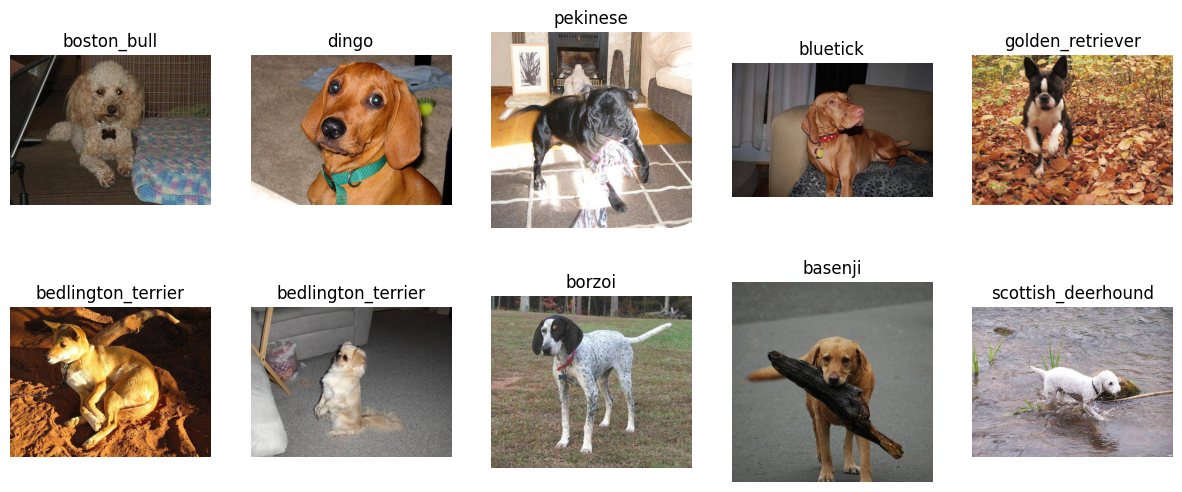

In [17]:
import matplotlib.pyplot as plt


num_images = 10

plt.figure(figsize=(15, 6))

for idx, item in enumerate(dataset):
    if idx >= num_images:
        break

    img = item["image"]
    label = item["label"]

    plt.subplot(2, 5, idx + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(str(label))

plt.show()

TASK 3


In [18]:
from PIL import Image
import numpy as np

def compute_stats(image_dir):
    widths, heights = [], []
    for fname in os.listdir(image_dir):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(image_dir, fname)
            try:
                with Image.open(path) as img:
                    w, h = img.size
                    widths.append(w)
                    heights.append(h)
            except Exception as e:
                print(f"Error with {fname}: {e}")
    return {
        'min_width': int(np.min(widths)),
        'max_width': int(np.max(widths)),
        'avg_width': float(np.mean(widths)),
        'min_height': int(np.min(heights)),
        'max_height': int(np.max(heights)),
        'avg_height': float(np.mean(heights)),
        'count': len(widths)
    }

train_dir = os.path.join(zip_dir, "train")
test_dir  = os.path.join(zip_dir, "test")

train_stats = compute_stats(train_dir)
test_stats  = compute_stats(test_dir)

# STEP 7: Pretty print the results
def print_stats(name, stats):
    print(f"\n{name} stats:")
    print(f"Min width:  {stats['min_width']}")
    print(f"Max width:  {stats['max_width']}")
    print(f"Avg width:  {stats['avg_width']:.2f}")
    print(f"Min height: {stats['min_height']}")
    print(f"Max height: {stats['max_height']}")
    print(f"Avg height: {stats['avg_height']:.2f}")
    print(f"Total images: {stats['count']}")

print_stats("Train", train_stats)
print_stats("Test", test_stats)


Train stats:
Min width:  97
Max width:  3264
Avg width:  443.33
Min height: 102
Max height: 2562
Avg height: 386.75
Total images: 10222

Test stats:
Min width:  100
Max width:  2592
Avg width:  441.76
Min height: 100
Max height: 2560
Avg height: 385.01
Total images: 10357


/tmp/ipython-input-3842552145.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=breed_counts.index, y=breed_counts.values, palette="Blues_d")


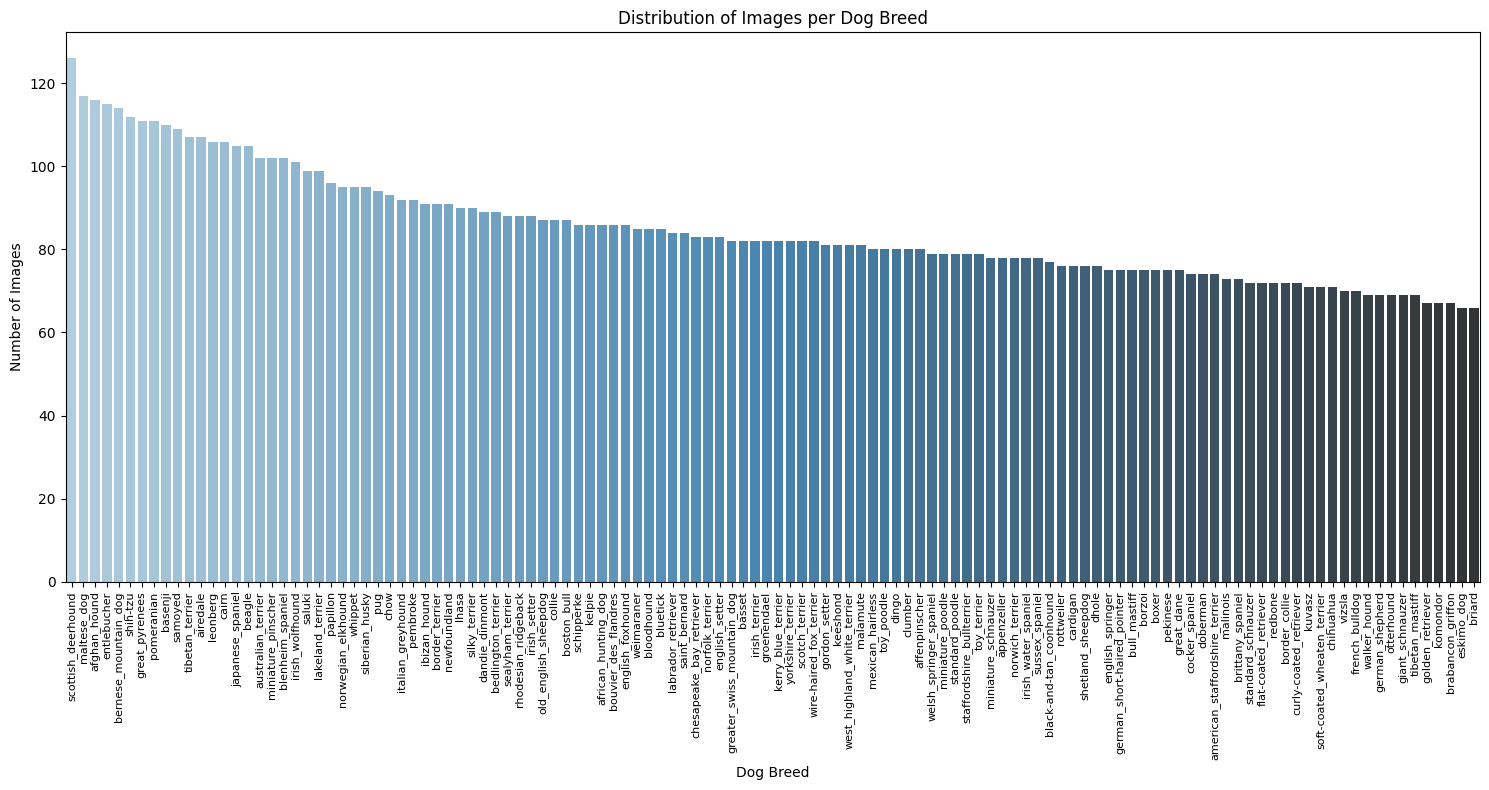

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Path to labels.csv (comes with dataset)
labels_path = os.path.join(zip_dir, "labels.csv")

# Load labels
labels_df = pd.read_csv(labels_path)

# Count images per breed
breed_counts = labels_df['breed'].value_counts()

# Plot
plt.figure(figsize=(15,8))
sns.barplot(x=breed_counts.index, y=breed_counts.values, palette="Blues_d")

plt.xticks(rotation=90, fontsize=8)
plt.xlabel("Dog Breed")
plt.ylabel("Number of Images")
plt.title("Distribution of Images per Dog Breed")

plt.tight_layout()
plt.show()


/tmp/ipython-input-2350525043.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.index, y=top10.values, palette="viridis")


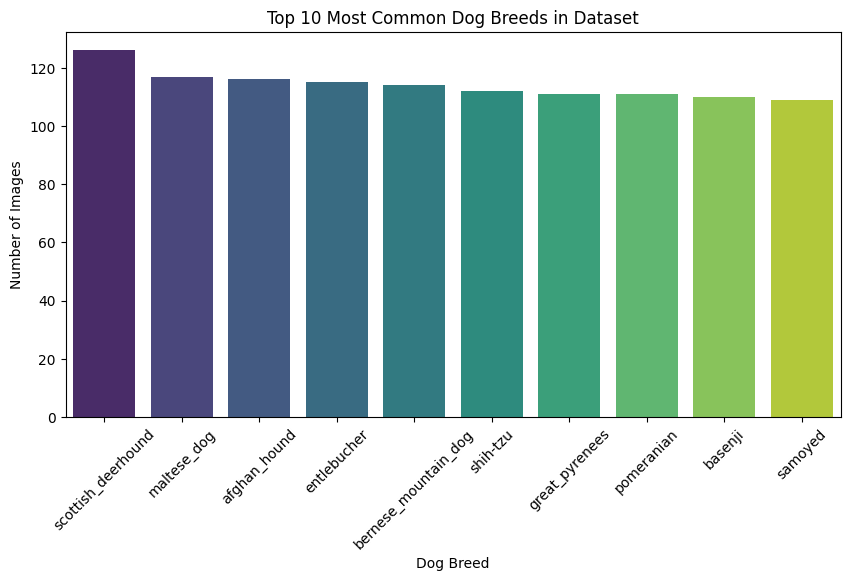

In [20]:
# Top 10 most frequent breeds
top10 = labels_df['breed'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top10.index, y=top10.values, palette="viridis")
plt.xticks(rotation=45)
plt.xlabel("Dog Breed")
plt.ylabel("Number of Images")
plt.title("Top 10 Most Common Dog Breeds in Dataset")
plt.show()


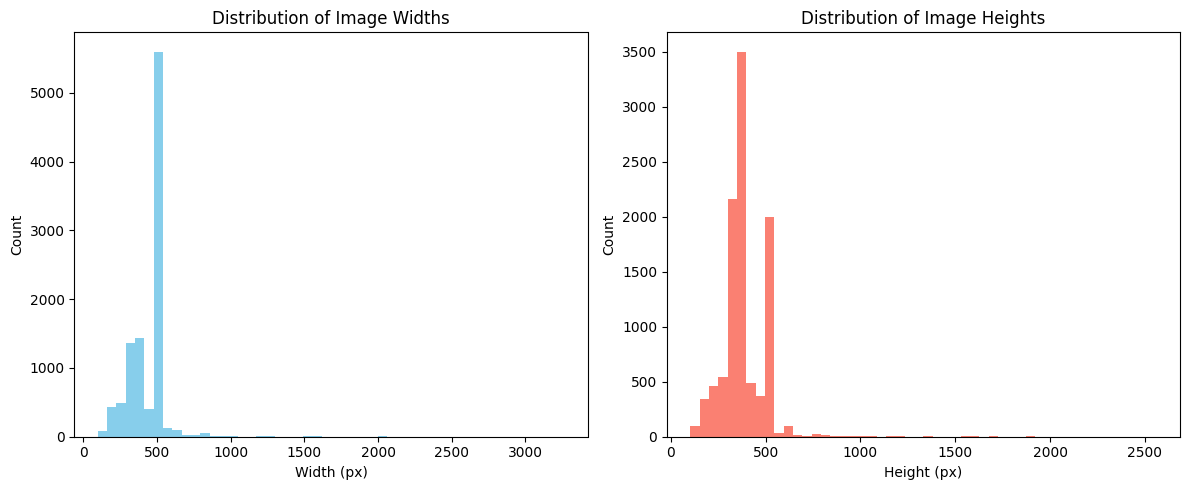

In [21]:
# Collect width & height of training images
from PIL import Image

widths, heights = [], []
for fname in os.listdir(train_dir):
    if fname.endswith(".jpg"):
        path = os.path.join(train_dir, fname)
        with Image.open(path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)

# Plot histogram for widths & heights
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(widths, bins=50, color="skyblue")
plt.xlabel("Width (px)")
plt.ylabel("Count")
plt.title("Distribution of Image Widths")

plt.subplot(1,2,2)
plt.hist(heights, bins=50, color="salmon")
plt.xlabel("Height (px)")
plt.ylabel("Count")
plt.title("Distribution of Image Heights")

plt.tight_layout()
plt.show()


📐 Average number of images per breed: 85.18


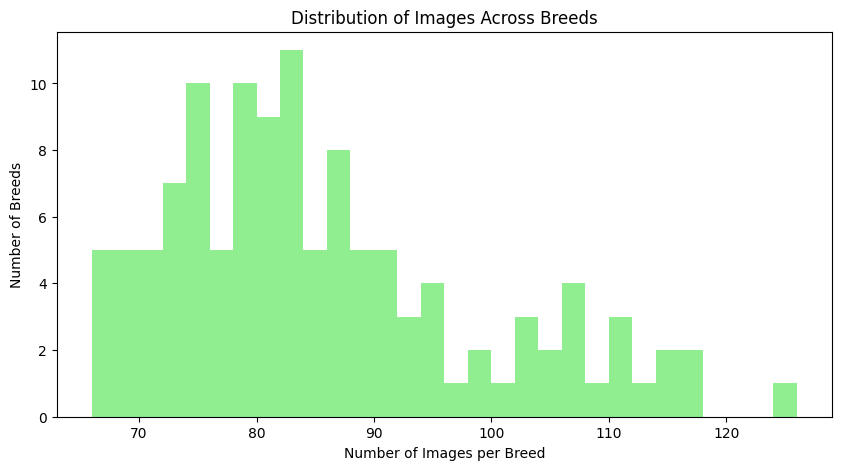

In [22]:
# Average number of images per breed
avg_per_breed = labels_df['breed'].value_counts().mean()

print(f"📐 Average number of images per breed: {avg_per_breed:.2f}")

# Histogram of images per breed
plt.figure(figsize=(10,5))
plt.hist(labels_df['breed'].value_counts(), bins=30, color="lightgreen")
plt.xlabel("Number of Images per Breed")
plt.ylabel("Number of Breeds")
plt.title("Distribution of Images Across Breeds")
plt.show()
